In [29]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

In [2]:
df = pl.read_parquet("../final_patient_data.parquet")


In [3]:
df.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1


In [4]:
cv_cols = [
    "Cardiopathie ischémique",
    "Fibrillation atriale",
    "Insuffisance cardiaque chronique",
    "Pacemaker",
    "Pontage aorto-coronarien",
    "Antécédent d'AVC",
]
df = df.with_columns(
    (
        pl.sum_horizontal([pl.col(c) for c in cv_cols]) >= 1
    )
    .cast(pl.Int8)
    .alias("cv_history")
)

In [5]:
df.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag,cv_history
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32,i8
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1,1


In [6]:
df = df.select([
    "patient_id", "hosp_admission_datetime", "death_date", "cv_history", "OMT_component_score"
])

In [8]:
df.head(5)

patient_id,hosp_admission_datetime,death_date,cv_history,OMT_component_score
str,datetime[μs],date,i8,i8
"""P001""",2018-07-04 11:15:00,2018-09-21,1,2
"""P002""",2019-01-18 13:20:00,null,0,0
"""P003""",2019-04-09 09:15:00,2020-12-04,1,2
"""P004""",2018-03-03 07:50:00,null,1,1
"""P005""",2019-02-01 14:10:00,2019-03-17,0,0


In [9]:
df = df.to_pandas()

In [10]:
# Convert to datetime and then extract the date only
# Normalize the time component to 00:00:00
df["hosp_admission_datetime"] = pd.to_datetime(df["hosp_admission_datetime"]).dt.normalize()
df["death_date"] = pd.to_datetime(df["death_date"]).dt.normalize()

In [11]:
# Create a one-year follow-up limit for each patient (admission date + 365 days)
df["one_year_limit"] = df["hosp_admission_datetime"]+pd.Timedelta(days=365)

In [12]:
df.head(1)

,patient_id,hosp_admission_datetime,death_date,cv_history,OMT_component_score,one_year_limit
0,P001,2018-07-04,2018-09-21,1,2,2019-07-04


In [13]:
# Define the actual end of follow-up for each patient:
# use the death date if available; otherwise, use the one-year limit
df["end_followup"] = df["death_date"].fillna(df["one_year_limit"])

# If the death date is beyond the one-year limit, censor follow-up at the one-year limit
df.loc[df["end_followup"] > df["one_year_limit"], "end_followup"] = (df["one_year_limit"])

In [14]:
# 3. Calculate the elapsed follow-up time in days
# This is the time variable used in the Kaplan-Meier estimator
df["time"] = (
    df["end_followup"]-df["hosp_admission_datetime"]
).dt.days

In [15]:
# 4. Determine whether death occurred within this follow-up period
# This is the status/event variable
df["status"] = (df["death_date"].notna()) & (
    df["death_date"] < df["one_year_limit"]
)

In [16]:
df.head()

,patient_id,hosp_admission_datetime,death_date,cv_history,OMT_component_score,one_year_limit,end_followup,time,status
0,P001,2018-07-04,2018-09-21,1,2,2019-07-04,2018-09-21,79,True
1,P002,2019-01-18,NaT,0,0,2020-01-18,2020-01-18,365,False
2,P003,2019-04-09,2020-12-04,1,2,2020-04-08,2020-04-08,365,False
3,P004,2018-03-03,NaT,1,1,2019-03-03,2019-03-03,365,False
4,P005,2019-02-01,2019-03-17,0,0,2020-02-01,2019-03-17,44,True


In [26]:
df_surv = df.loc[
    df['cv_history'] == 1,
    ['patient_id',  'time', 'status', 'OMT_component_score']
].copy()

In [27]:
df_surv.head()

,patient_id,time,status,OMT_component_score
0,P001,79,True,2
2,P003,365,False,2
3,P004,365,False,1
7,P008,209,True,0
9,P010,21,True,0


In [35]:
df_surv.isna().sum()

patient_id             0
time                   0
status                 0
OMT_component_score    0
dtype: int64

In [28]:
df_surv['OMT_component_score'].unique()

array([2, 1, 0], dtype=int8)

In [33]:
T = df_surv['time']
S = df_surv['status']

AttributeError: 'Series' object has no attribute 'ix'

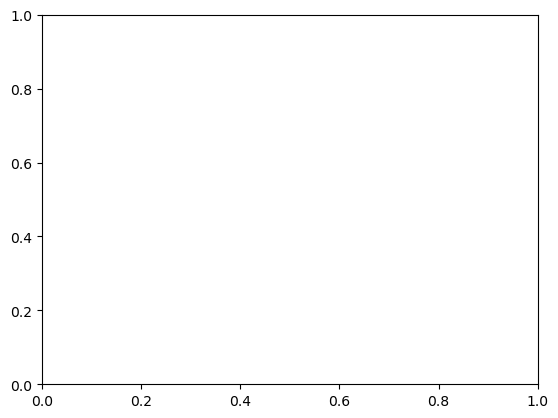

In [34]:
kmf = KaplanMeierFitter()
ax = plt.subplot(111)

for r in df_surv['OMT_component_score'].unique():
    ix = df_surv['OMT_component_score'] == r
    kmf.fit(T.ix[ix], S.ix[ix], label = r)
    ax = kmf.plot(ax = ax)